Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, death model vs. nonlinear transformation of mental health evaluation at discharge

|model                                       |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-------------------------------------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear                                      |Death |IBS           |Global | 0.0905991| 0.0040646| 0.0839322| 0.0981021| 25|
|Mental health evaluation at discharge (any) |Death |IBS           |Global | 0.1136585| 0.0048811| 0.1056373| 0.1219294| 25|
|Linear                                      |Death |Uno's C-Index |Global | 0.7423727| 0.0107173| 0.7237427| 0.7604639| 25|
|Mental health evaluation at discharge (any) |Death |Uno's C-Index |Global | 0.7423926| 0.0107388| 0.7236934| 0.7602795| 25|

### Readmission, Ordinal transformations

In [ ]:
#| label: shap-criteria-func-form-ordinal-test

gc()
future::plan(future::sequential)
gc()
future::plan(
  future::multisession,
  workers = 8,
  maxSizeOfObjects = 8 * 1024^3
)
options(future.globals.maxSize = 10 * 1024^3)  # 10 GiB


score_map <- list(
  eva_consumo = list(
    cont = "eva_consumo_score",
    cat  = c("eva_consumo_logro_intermedio", "eva_consumo_logro_minimo")
  ),
  eva_sm = list(
    cont = "eva_sm_score",
    cat  = c("eva_sm_logro_intermedio", "eva_sm_logro_minimo")
  ),
  eva_ocupacion = list(
    cont = "eva_ocupacion_score",
    cat  = c("eva_ocupacion_logro_intermedio", "eva_ocupacion_logro_minimo")
  ),
  eva_fisica = list(
    cont = "eva_fisica_score",
    cat  = c("eva_fisica_logro_intermedio", "eva_fisica_logro_minimo")
  ),
  eva_relinterp = list(
    cont = "eva_relinterp_score",
    cat  = c("eva_relinterp_logro_intermedio", "eva_relinterp_logro_minimo")
  ),
  eva_transgnorma = list(
    cont = "eva_transgnorma_score",
    cat  = c("eva_transgnorma_logro_intermedio", "eva_transgnorma_logro_minimo")
  ),
  eva_fam = list(
    cont = "eva_fam_score",
    cat  = c("eva_fam_logro_intermedio", "eva_fam_logro_minimo")
  ),
  ed_attainment = list(
    cont = "ed_attainment_score",
    cat  = c(
      "ed_attainment_corr_2_completed_high_school_or_less",
      "ed_attainment_corr_3_completed_primary_school_or_less"
    )
  ),
  prim_sub_freq = list(
    cont = "prim_sub_freq_score",
    cat  = c("prim_sub_freq_rec_2_2_6_days_wk", "prim_sub_freq_rec_3_daily")
  ), 
   urbanicity_cat = list(
    cont = "urbanicity_score",
    cat  = c("urbanicity_cat_2_mixed", "urbanicity_cat_1_rural"),
    weights = c(1, 2) # baseline: urban
  ),
  tenure_status_household = list(
    cont = "tenure_status_household_score",
    cat  = c(
      "tenure_status_household_others",
      "tenure_status_household_renting",
      "tenure_status_household_stays_temporarily_with_a_relative",
      "tenure_status_household_illegal_settlement"
    ),
    weights = c(1, 2, 3, 4) # baseline: owner/transferred/pays dividends
  )
)

add_boot_linear_terms <- function(df, score_map) {
  for (nm in names(score_map)) {
    m <- score_map[[nm]]

    if (all(m$cat %in% names(df))) {
      df[[m$cont]] <- df[[m$cat[1]]] * 1 + df[[m$cat[2]]] * 2
    } else {
      message("Skipping score construction for ", nm, ": missing ",
              paste(setdiff(m$cat, names(df)), collapse = ", "))
    }
  }

  df
}

py_corrected_datasets_boot <- lapply(
  py_corrected_datasets,
  add_boot_linear_terms,
  score_map = score_map
)


# ------------------------------------------------------------------
# Helper: RHS variable names from formula
# ------------------------------------------------------------------
rhs_vars <- function(f) {
  all.vars(stats::delete.response(stats::terms(f)))
}

predictor_available <- function(f, cat_vars) {
  vars <- rhs_vars(f)
  any(cat_vars %in% vars)
}

replace_cat_with_continuous <- function(formula_obj, cat_vars, cont_var) {
  response_txt <- paste(deparse(formula_obj[[2]]), collapse = "")
  term_labels <- attr(stats::terms(formula_obj), "term.labels")

  replace_one_term <- function(term) {
    parts <- strsplit(term, ":", fixed = TRUE)[[1]]

    parts_new <- ifelse(parts %in% cat_vars, cont_var, parts)

    paste(parts_new, collapse = ":")
  }

  new_terms <- vapply(term_labels, replace_one_term, character(1))
  new_terms <- unique(new_terms)

  stats::as.formula(
    paste(response_txt, "~", paste(new_terms, collapse = " + ")),
    env = environment(formula_obj)
  )
}

# ------------------------------------------------------------------
# Loop: replace each predictor only if present in readmission formula
# ------------------------------------------------------------------
results_list <- list()

base_readmit <- formula_shap_readmit_interact
base_death   <- formula_death_updated2

# Compute base AICc once
aic_cat <- compute_mi_aicc(base_readmit, py_corrected_datasets_boot)
aic_cat_val <- aic_cat$mean_aicc

for (nm in names(score_map)) {
  m <- score_map[[nm]]

  if (!predictor_available(base_readmit, m$cat)) {
    cat("\n>>> Skipping:", nm, "- not in readmission formula <<<\n")
    next
  }

  cat("\n>>> Processing:", nm, "<<<\n")

  f_readmit_cont <- replace_cat_with_continuous(
    formula_obj = base_readmit,
    cat_vars    = m$cat,
    cont_var    = m$cont
  )

  aic_cont <- compute_mi_aicc(f_readmit_cont, py_corrected_datasets_boot)
  aic_cont_val <- aic_cont$mean_aicc

  cat(
    "  AICc categorical:", aic_cat_val,
    "| continuous:", aic_cont_val,
    "| delta:", round(aic_cont_val - aic_cat_val, 3), "\n"
  )

  gc()

  res <- evaluate_dual_cox_python_style(
    formula_readmit = f_readmit_cont,
    formula_death   = base_death,
    imputed_list    = py_corrected_datasets_boot,
    k_folds         = 5,
    eval_times      = c(60, 108)
  )

  results_list[[nm]] <- res
  cat("  Done.\n")
}



AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272712.30
Mean AICc: 272712.38
Correction added (Penalty): 0.078833
Parameters (k): 24 | Effective Sample Size (Events): 15247

>>> Processing: eva_consumo <<<

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272714.30
Mean AICc: 272714.37
Correction added (Penalty): 0.072522
Parameters (k): 23 | Effective Sample Size (Events): 15247
  AICc categorical: 272712.4 | continuous: 272714.4 | delta: 1.991 
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: 


# Final SHAP model



In [ ]:
#| label: final-shap-build-splines

gc()

             used   (Mb) gc trigger    (Mb)   max used    (Mb)
Ncells    6421303  343.0   10743420   573.8   10743420   573.8
Vcells 1279867518 9764.7 2083736386 15897.7 1769896875 13503.3

In [ ]:
#| label: final-shap-rank-models

#2. Rank models across your imputed dataset list
safe_cox <- function(formula, data) {
  base::tryCatch(
    survival::coxph(
      formula,
      data = data,
      ties = "efron",
      x = TRUE,
      y = TRUE
    ),
    error = function(e) NULL
  )
}
rank_models <- function(forms, data_list) {
  purrr::map_dfr(names(forms), function(nm) {
    fits <- purrr::map(data_list, ~ safe_cox(forms[[nm]], .x))
    aics <- purrr::map_dbl(fits,~ if (base::is.null(.x)) NA_real_ else stats::AIC(.x))
    tibble::tibble(
      model = nm,
      n_fit = base::sum(!base::is.na(aics)),
      median_AIC = stats::median(aics, na.rm = TRUE),
      mean_AIC = base::mean(aics, na.rm = TRUE)
    )
  }) |>
    dplyr::arrange(median_AIC)
}

In [ ]:
#| label: final-shap-plug-to-cv
#4. Plug directly into your existing CV evaluation

readm_forms <- list(
    base_shap_int = formula_shap_readmit_interact,
    spline_main   = formula_readmit_int_spline#,
    #spline_i1     = formula_readmit_int_spline_i1
)
death_forms <- list(
    base_shap_int = formula_shap_death_interact,
    spline_main   = formula_death_int_spline
)

rank_models(readm_forms, py_corrected_datasets_boot)

rank_models(death_forms, py_corrected_datasets_boot)

# A tibble: 2 × 4
  model         n_fit median_AIC mean_AIC
  <chr>         <int>      <dbl>    <dbl>
1 spline_main       5     54159.   54156.
2 base_shap_int     5     54188.   54186.

In [ ]:
compare_mi_models_d1(formula_readmit_int_spline, formula_shap_readmit_interact, py_corrected_datasets_boot)
compare_mi_models_d1(formula_death_int_spline, formula_shap_death_interact, py_corrected_datasets_boot)

Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test statistic df1   df2 dfcom      p.value           riv
 1 ~~ 2   21.7288  10 15213 15215 8.057224e-41 0.00002704545
Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test statistic df1      df2 dfcom       p.value         riv
 1 ~~ 2  113.0172   9 3009.028  3013 4.982305e-183 0.002491375


In [ ]:
#| label: final-shap-int-spline-eval
options(future.globals.maxSize = 12 * 1024^3)

#formula_death_int_spline
results_readmit_int_shap_spl <- evaluate_mi_cv_safe_strata(
    formula = formula_readmit_int_spline, 
    imputed_list = py_corrected_datasets_boot, 
    time_col = "readmit_time_from_disch_m", 
    event_col = "readmit_event",
    k = 5,
    n_repeats = 20
)#
results_death_int_shap_spl <- evaluate_mi_cv_safe_strata(
    formula = formula_death_int_spline, 
    imputed_list = py_corrected_datasets_boot, 
    time_col = "death_time_from_disch_m", 
    event_col = "death_event",
    k = 5,
    n_repeats = 20
)
results_readmit_shap_int_spl_ibs <- cph_evaluate_boot_oob_mi_corrected(
    formula = formula_readmit_int_spline,
    imputed_list = py_corrected_datasets_boot, # List of data.frames
    time_col = "readmit_time_from_disch_m", 
    event_col = "readmit_event",
    tau = 99,                # Evaluate up to 60 months
    B = 500,
    cpus = cpus,
    verbose = TRUE,
    min_strata_events = 1
)
results_death_shap_int_spl_ibs <- cph_evaluate_boot_oob_mi_corrected(
    formula = formula_death_int_spline,
    imputed_list = py_corrected_datasets_boot, # List of data.frames
    time_col = "death_time_from_disch_m", 
    event_col = "death_event",
    tau = 107,                # Evaluate up to 60 months
    B = 500,
    cpus = cpus,
    verbose = TRUE,
    min_strata_events = 1
)
# ====
aicc_readmit_shap_int_spl <- compute_mi_aicc(formula_readmit_int_spline, py_corrected_datasets_boot)
aicc_readmit_shap_int_spl
aicc_death_shap_int_spl <- compute_mi_aicc(formula_death_int_spline, py_corrected_datasets_boot)
aicc_death_shap_int_spl


Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 Total Models
------------------------------------------------------------
Global evaluation tau: 99.10 months | C-tau: 94.14 months
Booting up 16 CPU cores using future backend...

FINAL POOLED RESULTS (Cross-Validated + Multiply Imputed)
Global Evaluation Time (tau): 99.10 months
Pooled Uno's C-Index: 0.6096 (repeat-quantile interval 0.6093-0.6100)
Pooled UnoC (survAUC::UnoC): 0.6764 (repeat-quantile interval 0.6436-0.6923)
Pooled IBS: 0.1605 (repeat-quantile interval 0.1604-0.1605)
Pooled IBS (IPCW-train): 0.3480 (repeat-quantile interval 0.3479-0.3482)
RMST-based Uno C-index by horizon:
  t=12 m: C=0.6310 (repeat-quantile interval 0.6306-0.6313, valid repeats=20)
  t=36 m: C=0.6165 (repeat-quantile interval 0.6162-0.6168, valid repeats=20)
  t=60 m: C=0.6126 (repeat-quantile interval 0.6122-0.6129, valid repeats=20)

Total runtime: 869.90 sec (14.50 min)
Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 To

There were 50 or more warnings (use warnings() to see the first 50)


Strata variables: plan_type_strata
Categorical vars: plan_type_strata
Bootstrap OOB + MI: B=500, M=5, tau=107.00
Using 8 worker(s)...

FINAL POOLED RESULTS (OOB Bootstrap + MI)
Pooled OOB IBS: 0.0893 (95% CI: 0.0826 - 0.0963)
Valid bootstrap replicates: 500 / 500


There were 16 warnings (use warnings() to see them)



AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272443.79
Mean AICc: 272443.93
Correction added (Penalty): 0.138820
Parameters (k): 32 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  54156.44
Mean AICc: 54156.90
Correction added (Penalty): 0.466135
Parameters (k): 26 | Effective Sample Size (Events): 3039


$mean_aicc
[1] 54156.9

$full_results
       aic correction     aicc  k n_events
1 54144.71  0.4661355 54145.17 26     3039
2 54166.42  0.4661355 54166.88 26     3039
3 54161.88  0.4661355 54162.34 26     3039
4 54158.60  0.4661355 54159.06 26     3039
5 54150.58  0.4661355 54151.05 26     3039


In [ ]:
cal_readmit_shap_int_spl_ici <- calibrate_cph_grouped(
    formula = formula_readmit_int_spline,
    data = py_corrected_datasets_boot,
    times = c(12, 36, 60),
    validation = "cv",
    folds = 5,
    n_repeats = 20,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE
)
print(cal_readmit_shap_int_spl_ici)

Detected time variable: readmit_time_from_disch_m
Detected event variable: readmit_event
Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 60.
Predicting repetition 1/20... done
Predicting repetition 2/20... done
Predicting repetition 3/20... done
Predicting repetition 4/20... done
Predicting repetition 5/20... done
Predicting repetition 6/20... done
Predicting repetition 7/20... done
Predicting repetition 8/20... done
Predicting repetition 9/20... done
Predicting repetition 10/20... done
Predicting repetition 11/20... done
Predicting repetition 12/20... done
Predicting repetition 13/20... done
Predicting repetition 14/20... done
Predicting repetition 15/20... done
Predicting repetition 16/20... done
Predicting repetition 17/20... done
Predicting repetition 18/20... done
Predicting repetition 19/20... done
Predicting repetition 20/20... done
Calibrating repetition 1/20... done
Calibrating rep

Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 60.
Predicting repetition 1/20... done
Predicting repetition 2/20... done
Predicting repetition 3/20... done
Predicting repetition 4/20... done
Predicting repetition 5/20... done
Predicting repetition 6/20... done
Predicting repetition 7/20... done
Predicting repetition 8/20... done
Predicting repetition 9/20... done
Predicting repetition 10/20... done
Predicting repetition 11/20... done
Predicting repetition 12/20... done
Predicting repetition 13/20... done
Predicting repetition 14/20... done
Predicting repetition 15/20... done
Predicting repetition 16/20... done
Predicting repetition 17/20... done
Predicting repetition 18/20... done
Predicting repetition 19/20... done
Predicting repetition 20/20... done
Calibrating repetition 1/20... done
Calibrating repetition 2/20... done
Calibrating repetition 3/20... done
Calibrating repetition 4/20... d

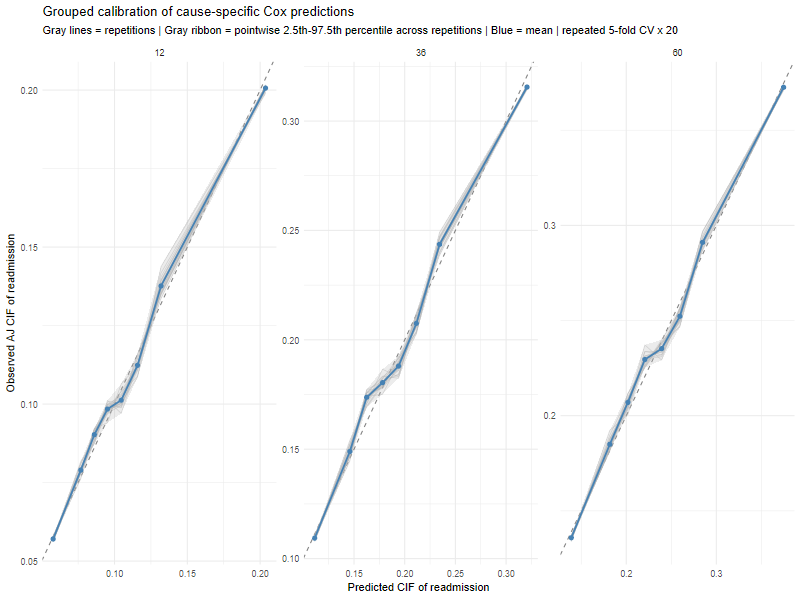

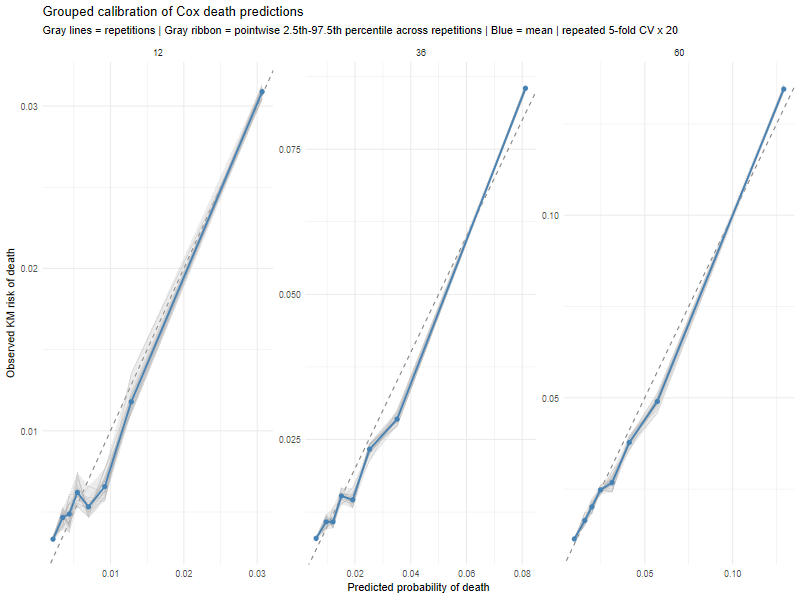

In [ ]:
#| label: calib-shap
gc()
cal_readmit_aj_rcv <- calibrate_cscox_aj_grouped(
    formula_readmit = formula_readmit_int_spline,
    formula_death = formula_death_int_spline,
    data = py_corrected_datasets_boot,
    times = c(12, 36, 60),
    n_imputations = 5,
    validation = "cv",
    folds = 5,
    n_repeats = 20,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE,
    g = 10,
    min_bin_n = 20,
    seed = 2125
)
print(cal_readmit_aj_rcv)
plot(cal_readmit_aj_rcv)


cal_death_ici <- calibrate_cph_grouped(
    formula = formula_death_int_spline,
    data = py_corrected_datasets_boot,
    times = c(12, 36, 60),
    validation = "cv",
    folds = 5,
    n_repeats = 20,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE
)
print(cal_death_ici)
plot(cal_death_ici)

# Methods
# We fitted cause-specific Cox models for readmission and death, and combined them to estimate the predicted cumulative incidence of readmission at 12, 36, and 60 months. Calibration was assessed by comparing grouped predicted risks against observed Aalen–Johansen estimates of readmission, thereby accounting for the competing risk of death. To reduce optimism, calibration was evaluated using 5-fold cross-validation across imputations.
# 
# Results
# The cause-specific Cox models showed excellent calibration for readmission risk at all evaluated horizons. Cross-validated expected-to-observed ratios were 0.99 at 12 months, 0.99 at 36 months, and 0.98 at 60 months, indicating minimal miscalibration in the large. Grouped expected calibration error was also very low across horizons (12 months: 0.0029; 36 months: 0.0041; 60 months: 0.0040).
# One thing: in your message, the printed output corresponds to one fitted object, but the second call with formula_readmit_int_spline2 and formula_death_int_spline does not show its printed result yet. So I can interpret the first object with certainty; for the second one, I’d need the printed summary too.


In [ ]:
#| label: dual-cox

# Define your model formula
formula_death <- Surv(death_time_from_disch_m, death_event) ~ 
  age + sex + plan_type_corr + comorbidity_score + strata(plan_type_strata)

results_boot <- evaluate_dual_cox_python_style(
  formula_readmit = formula_readmit_int_spline,
  formula_death = formula_death_int_spline,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3, 6, 9, 12, 24, 36, 48, 60, 72, 84, 96, 108)
)


Starting dual Cox evaluation: 5 imputations x 10 folds = 50 fold pairs
Imp 1/5: ..........
Imp 2/5: ..........
Imp 3/5: ..........
Imp 4/5: ..